# Name: Haikun Xue

# Submission
You do not need to write up a separate report since there will be space for you to write down thoughts/answer questions throughout this notebook. Instead, when you are finished, go to File --> Save and Export Notebook As --> LaTeX (or as pdf, but this option hasn't been working). This will convert the notebook to a .tex file which can be uploaded into Overleaf and compiled into an already formatted pdf. 

# Introduction
This homework goes over the concepts of calculating $\chi^{2}$ and reduced $\chi^{2}$ to see the goodness of fit of a model to provided data. We then implement an offshoot of this through Markov Chain Monte Carlo (MCMC) Simulations, which use a maximum log-likelihood to judge goodness of fit. It is important to note that maximizing log-likelihood is the same as minimizing chi-squared.

Please watch the following videos, then start filling in the below notebook cells to complete the problems.

Required videos to watch:
1. An introduction to $\chi^{2}$ and reduced $\chi^{2}$: https://www.youtube.com/watch?v=KNLhep3UZ68
2. An introduction to the background of MCMC Simulations: https://www.youtube.com/watch?v=nndtTssgtZE

Optional supplemental materials to read for $\chi^{2}$ and MCMC:
1. https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf - Read sections 2.3-2.4 and 3
2. https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html - Implementation of MCMC

Chi Squared
-
Equation for it:
$$\chi^{2} = \sum_{i=1}^{N}{\frac{(y_{i}^{OBS}-y_{i}^{MOD})^{2}}{\epsilon_{y_{i}}^{2}}}$$
where $y_{i}^{OBS}$ are the data/observations with error estimation $\epsilon_{y_{i}}$, and $y_{i}^{MOD}$ is the model function.

Reduced Chi-Squared
-
Another important value is the number of degrees of freedom in the model, $\nu$, defined as 
$$\nu = n - p$$
where $n$ is the number of datapoints (measurements) and $p$ are the number of fitted parameters. 

With this, we can determine how well the model has fit the data by using the reduced $\chi^{2}_{\nu}$ which is defined as the chi-square per degree of freedom:

$$\chi^{2}_{\nu} = \frac{\chi^{2}}{\nu}$$

To determine how well the model has fit the data, we use the reduced $\chi^{2}_{\nu}$:
- $\chi^{2}_{\nu} < 1 \rightarrow$ over-fitting of the data
- $\chi^{2}_{\nu} > 1 \rightarrow$ poor model fit
- $\chi^{2}_{\nu} \simeq 1 \rightarrow$ good match between data and model in accordance with the data error

Taken from: https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf (Section 2.3)

In [107]:
#Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Simple power law [0.5 pts]

To get started, run the cell below. It's some fake noisy data that forms a power law to help ensure that your code is working. Feel free to change the parameters. The model for this problem is the power law which takes the functional form
$$y = Ax^{k}$$
where $A$ is a constant and $k$ is the exponent (or power law index). 

The goal is to explore how $\chi^{2}$ explores the parameter space for two parameters (A and k) by making a brute force $\chi^{2}$ algorithm. 

In [108]:
np.random.seed(42) #just so I get the same values as I repeat the procedure as a check to make sure things work

#power law params
A = 5        
k= -1.7 
x = np.linspace(1, 100, 100) #range of x values 
y_true = A*x**k #eqn without noise

noise = np.random.normal(0, 0.20 * y_true) #noise 

y = y_true + noise #the equation I want the model to fit to
y_err = 0.2*y_true #just some errors - they are Gaussian!

The first thing to do is make some functions for the model, $\chi^{2}$, and $\chi^{2}_{\nu}$.

In [109]:
# Define functions

def chi2(data,model, err):
    chi2 = np.sum((data - model)**2 / err**2)
    return chi2


def chi2red(data,model,err,nu ):
    chi2 = np.sum((data - model)**2 / err**2)
    return chi2/nu

In [110]:
chi2red(y,y_true,y_err,98)

np.float64(0.8441900957844286)

### Two Parameter Fit [2 pts]
Start with the two parameter fit in which for each combination of $A$ and $k$, a $\chi^{2}$ and $\chi^{2}_{\nu}$ is computed. Print out some of these values for a few of the iterations to see how they change. What do you notice? Hint: Define a grid of values for $\chi^{2}$ to search through. 


Note: This is a brute force method that explores the whole defined parameter space. It does not try to get the lowest-chi squre value.

In [112]:
# Two param fit
n = 100
A_para = np.linspace(0,10,n)
k_para = np.linspace(-2,2,n)
chi2_array = np.zeros([n,n])
for i,A in enumerate(A_para):
    for j, K in enumerate(k_para):
        y_temp = A* x**K 
        chi2_array[i,j] = chi2(y,y_temp,y_err)
chi2_array[:5,:5]


array([[2478.88411199, 2478.88411199, 2478.88411199, 2478.88411199,
        2478.88411199],
       [2444.14679805, 2439.17560054, 2433.40054401, 2426.68625442,
        2418.87434252],
       [2409.69216523, 2399.82513499, 2388.37547114, 2375.08143198,
        2359.63862728],
       [2375.52021354, 2360.83271534, 2343.80889337, 2324.06964467,
        2301.17696627],
       [2341.63094297, 2322.19834159, 2299.7008107 , 2273.65089248,
        2243.48935951]])

Comments: The brute-force grid search seems to narrow in on the results

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. 

In [43]:
# Get the best values - The printed output is fine
dof = len(y) -2 
red_chi2_array = chi2_array / dof

min_idx = np.unravel_index(np.argmin(red_chi2_array), red_chi2_array.shape)

best_A = A_para[min_idx[0]]
best_K = k_para[min_idx[1]]
best_red_chi2 = red_chi2_array[min_idx]

print(f"The lowest reduced chi-square is {best_red_chi2:.4f}")
print(f"Best-fit A = {best_A:.4f}")
print(f"Best-fit K = {best_K:.4f}")

The lowest reduced chi-square is 0.8357
Best-fit A = 5.2525
Best-fit K = -1.7172


Plot the data, model with the best-fit parameters, and residuals in log-log space (You should see a line). Comment on the fit.

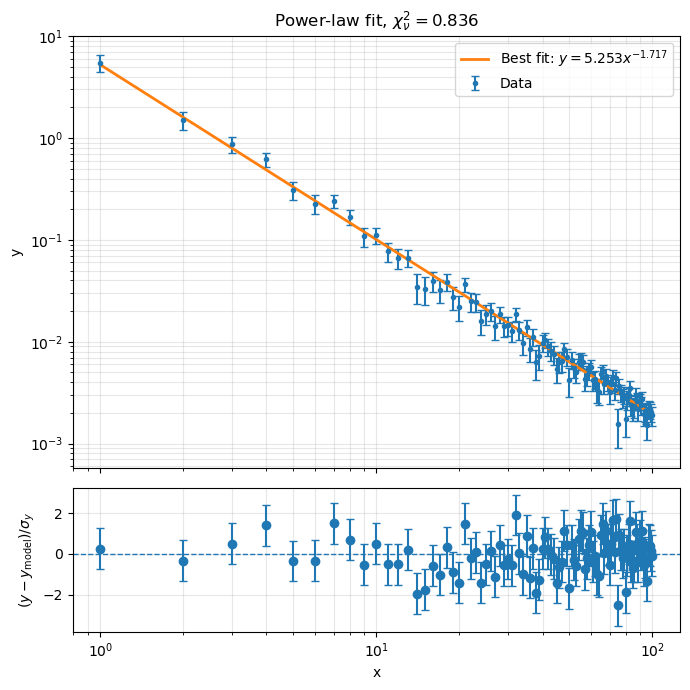

In [44]:
y_best = best_A * x**best_K
residual = y - y_best
norm_residual = residual / y_err


fig, ax = plt.subplots(
    2, 1,
    figsize=(7, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)


ax[0].errorbar(x,y,yerr=y_err,fmt=".",capsize=3,label="Data")

ax[0].plot(x,y_best,linewidth=2,label=fr"Best fit: $y = {best_A:.3f}x^{{{best_K:.3f}}}$")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_ylabel("y")
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

ax[0].set_title(fr"Power-law fit, $\chi^2_\nu = {best_red_chi2:.3f}$")


ax[1].axhline(0, linestyle="--", linewidth=1)

ax[1].errorbar(x,norm_residual,yerr=np.ones_like(norm_residual),fmt="o",capsize=3)

ax[1].set_xscale("log")
ax[1].set_xlabel("x")
ax[1].set_ylabel(r"$(y-y_{\rm model})/\sigma_y$")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

Comments: It describe the data well! As expected

We can also see how how $\chi^{2}$ changes as it cycles through the different combinations of parameters. To do this, make a contour plot of $A$ vs $k$ with a colorbar indicating $\chi^{2}$. Include a point indicating your best fit parameters. Comment on the parameter space in relation to thest best-fit values.

Hint: Use LogNorm for the colorbar. The plot should look choppy if you have a low grid resolution, which is fine. If you want, you can make a finer grid, but that will very quickly make the $\chi^{2}$ search become more computationally expensive. 

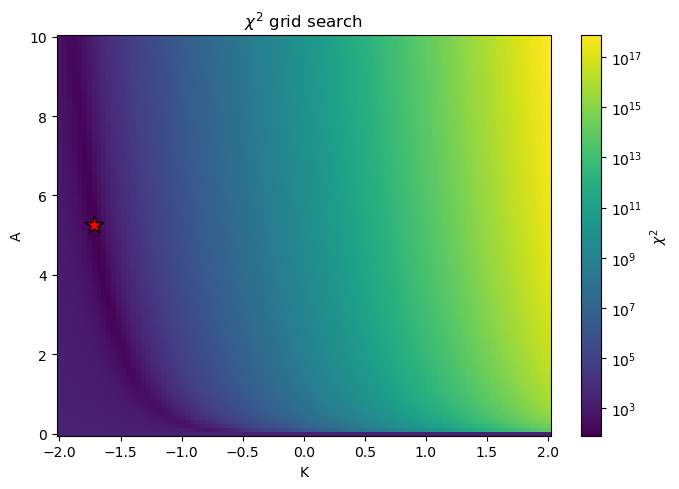

In [45]:
# Contour plot
from matplotlib.colors import LogNorm
K_grid, A_grid = np.meshgrid(k_para, A_para)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.pcolormesh(K_grid,A_grid,chi2_array,shading="auto",norm=LogNorm())

ax.scatter(best_K,best_A,marker="*",s=180,color ="red",edgecolor="black",label="Best fit")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\chi^2$")

ax.set_xlabel("K")
ax.set_ylabel("A")
ax.set_title(r"$\chi^2$ grid search")

plt.tight_layout()
plt.show()

Comments: There is a line of close to best fit chi square, indicating there is a specific relationship between A and K that reproduce data the best.

## Real Data [2 pts]
Now let's apply what we've done from before to some real data. Download Stellar_Data.txt which holds mass ($M_{\odot}$), log stellar age (log years), log accretion rate (log $M_{\odot}/yr$), and log accretion rate errors. Note: The data is already in log scale, so how will that change your model function?

In [46]:
# Load in the data
stellar_df = pd.read_csv("HW07_Stellar_Data.txt", delim_whitespace=True)
stellar_df

/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_98283/497887955.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  stellar_df = pd.read_csv("HW07_Stellar_Data.txt", delim_whitespace=True)


,Mstar,logAge,logMacc,logMaccErr
0,1.931,6.57,-8.082,0.225
1,1.802,6.69,-8.268,0.457
2,1.612,6.86,-8.097,0.161
3,1.616,6.90,-8.036,0.174
4,0.759,5.99,-8.195,0.285
...,...,...,...,...
229,0.656,5.92,-7.888,0.173
230,0.490,6.45,-8.933,0.145
231,1.055,6.60,-8.914,0.266
232,1.271,7.24,-7.533,0.289


In [47]:
# New model function here
n_entries = len(stellar_df)

#log scale chi2
def chi2_s(data,model, err):
    chi2 = np.sum(((data - model)/err)**2)
    return chi2


Use the brute force method for two parameters from before. Play around with your parameter space and print out some parameters with their $\chi^{2}$, and $\chi^{2}_{\nu}$. Comment on what you notice about these values.

In [114]:
# Brute force method
n = 100
nu = n_entries-2
x = stellar_df['logAge']
y = stellar_df['logMacc']
y_err = stellar_df['logMaccErr']

As_para = np.linspace(-3,3,n)
ks_para = np.linspace(-25,10,n)
chi2_sarray = np.zeros([n,n])
for i,A in enumerate(As_para):
    for j, K in enumerate(ks_para):
        y_temp = A* x+ K 
        chi2_sarray[i,j] = chi2_s(y,y_temp,y_err)
chi2_sarray[:5,:5]


array([[32178806.82794115, 31555717.67849842, 30938735.69768026,
        30327860.88548671, 29723093.24191774],
       [31487995.21830571, 30871646.4573782 , 30261404.86507528,
        29657270.44139694, 29059243.18634321],
       [30804702.91916026, 30195094.54674798, 29591593.34296029,
        28994199.30779718, 28402912.44125867],
       [30128929.9305048 , 29526061.94660775, 28929301.1313353 ,
        28338647.48468741, 27754101.00666412],
       [29460676.25233933, 28864548.65695752, 28274528.23020028,
        27690614.97206763, 27112808.88255956]])

Comments: The numbers are MUCH larger, which means the fit might be worse

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding parameters and $\chi^{2}$. These are your best fit parameters.

In [71]:
# Best-fit params
chi2red_sarray = chi2_sarray/nu

min_idx = np.unravel_index(np.argmin(chi2_sarray), chi2_sarray.shape)

best_As = As_para[min_idx[0]]
best_Ks = ks_para[min_idx[1]]
best_chi2s = chi2_sarray[min_idx]
best_red_chi2s = chi2red_sarray[min_idx]

print(f"Best A = {best_As:.4f}")
print(f"Best K = {best_Ks:.4f}")
print(f"Lowest chi2 = {best_chi2s:.4f}")
print(f"Lowest reduced chi2 = {best_red_chi2s:.4f}")

Best A = -0.3333
Best K = -5.9091
Lowest chi2 = 4071.0716
Lowest reduced chi2 = 17.5477


As before, plot the data with errors, model with the best-fit parameters, and residuals in log-log space. Make sure to include units on the plot. Comment on the fit. Look back at $\chi^{2}_{\nu}$ value you got, what does this value mean for your model? How could one improve $\chi^{2}_{\nu}$? 

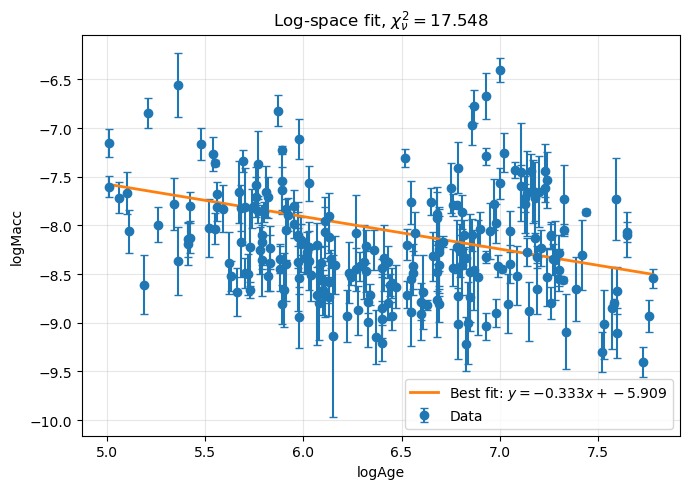

In [ ]:
# Plot it up
y_best = best_As * x + best_Ks

sort_idx = np.argsort(x)

plt.figure(figsize=(7, 5))

plt.errorbar(x,y,yerr=y_err,fmt="o",capsize=3,label="Data")

plt.plot(x[sort_idx],y_best[sort_idx],linewidth=2,label=fr"Best fit: $y = {best_As:.3f}x + {best_Ks:.3f}$")

plt.xlabel("logAge")
plt.ylabel("logMacc")
plt.title(fr"Log-space fit, $\chi^2_\nu = {best_red_chi2s:.3f}$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Comments: There are much more scatter and not a clear "best fit line", so the simple powerlaw might not be the best model

Also, make the contour plot of parameter 1 vs parameter 2 with a colorbar indicating $\chi^{2}$ again. Add the point indicating your best-fit parameters. Comment on the parameter space in relation to these best-fit values. 

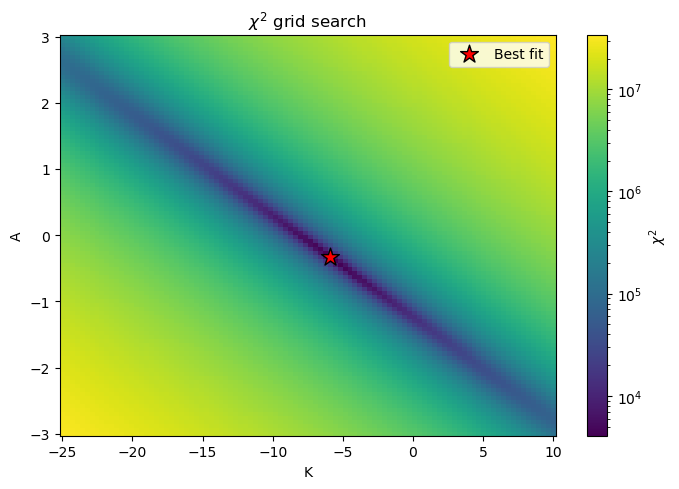

In [74]:
# Contour plot


K_grid, A_grid = np.meshgrid(ks_para, As_para)

chi2_plot = chi2_sarray.copy()

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.pcolormesh(K_grid,A_grid,chi2_plot,shading="auto",norm=LogNorm())

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\chi^2$")

ax.scatter(best_Ks, best_As,marker="*", s=180, color = "red", edgecolor="black",label="Best fit")

ax.set_xlabel("K")
ax.set_ylabel("A")
ax.set_title(r"$\chi^2$ grid search")
ax.legend()

plt.tight_layout()
plt.show()

Comments: We do see a line trend at the middle of the graph, where the best fit lies 

# Fitting Stellar Accretion [5.5 pts]

In this part we are going to be using the the emcee package to run MCMC on a data set for stellar accretion
https://emcee.readthedocs.io/en/stable/

We will work through the steps in https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html to set up the MCMC.

In [75]:
import emcee

First, load Stellar_Data.txt into the notebook and make a scatter plot of logAge vs logMacc. Note: the data is already logarithmic. [0.5 pts]

Text(0.5, 1.0, 'Age vs Macc')

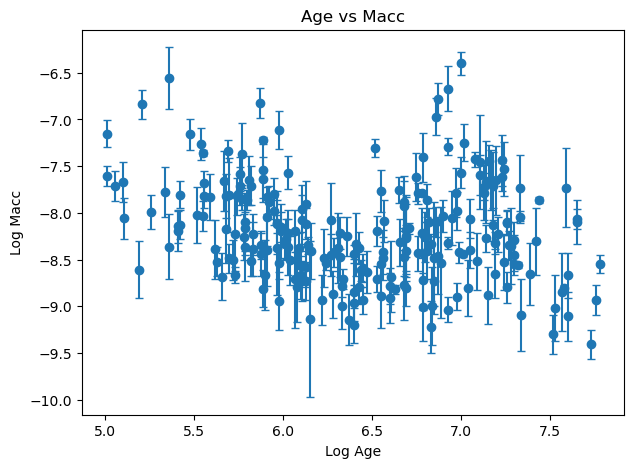

In [79]:
# Load data and plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(x,y,yerr=y_err,fmt="o",capsize=3,label="Data")

ax.set_xlabel("Log Age")
ax.set_ylabel("Log Macc")
ax.set_title(r"Age vs Macc")

Create the linear model definition, the log likelihood definition, the lnprior definition, and the posterior probability definition. [1 pnt]

In [95]:
nu = n_entries-2
x = stellar_df['logAge']
y = stellar_df['logMacc']
y_err = stellar_df['logMaccErr']

# Linear Model Def
def model(theta, age = x):
    A, K = theta
    return A* age+ K 

# Log Likelihood Def
def lnlike(theta,x,y,y_err):
    return -0.5*np.sum(((y-model(theta,x))/y_err )**2)

# lnprior Def
def lnprior(theta):
    A,K = theta
    if -3.0 < A < 3.0 and -25.0 < K < 5.0:
        return 0.0
    return -np.inf 

# Posterior Prob Def
def lnprob(theta,x,y,yerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp+ lnlike(theta,x,y,yerr)

Use the definitions to run the emcee. Your number of walkers should be some power of 2, and your number of iterations should be some value over 100. [1 pts]

In [100]:
# Parameters
data = (x,y,y_err)
nwalkers = 128
niter = 200
initial = np.array([0,0])
ndim = len(initial)
p0 = [np.array(initial)+ 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]
# Run MCMC
def main(p0,nwalkers,niter,ndim,lnprob,data):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data)

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100)
    sampler.reset()

    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter)

    return sampler, pos, prob, state
sampler, pos, prob, state = main(p0,nwalkers,niter,ndim,lnprob,data)

Running burn-in...
Running production...


Make a plot of the parameters' values over each step (typically referred to as a convergence or trace study). Comment on the value of the parameters as the MCMC runs. Hint: This information is encoded in the get_chain() function. [1 pnt]

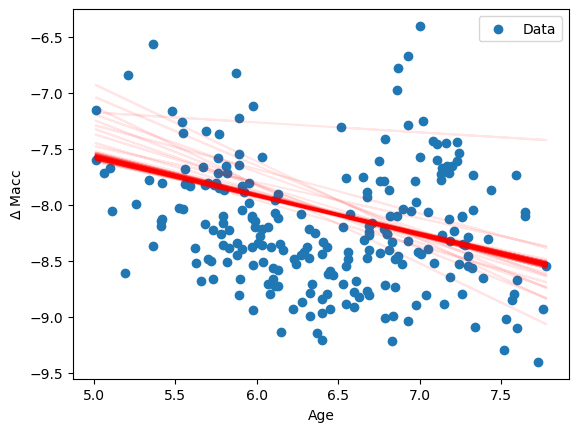

In [101]:
# Plot parameter values versus steps (iterations)
def plotter(sampler,age=x,T=y):
    plt.ion()
    plt.scatter(x,y,label='Data')
    samples = sampler.flatchain
    for theta in samples[np.random.randint(len(samples), size=100)]:
        plt.plot(age, model(theta, age), color="r", alpha=0.1)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.xlabel('Age')
    plt.ylabel(r'$\Delta$ Macc')
    plt.legend()
    plt.show()
plotter(sampler)

After running emcee, plot the original data with the best fit line calculated from the emcee. Comment on the plot. [1 pnt]

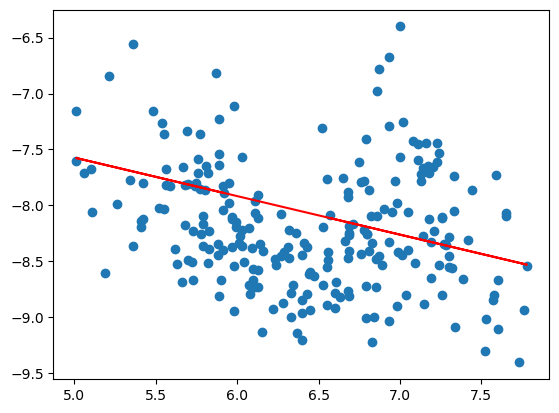

Theta max:  [-0.3444992  -5.85004673]


In [99]:
# Plot data and best-fit line
samples = sampler.flatchain

theta_max  = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(theta_max)
plt.scatter(x,y,label='Data')
plt.plot(x,best_fit_model, color = "red",label='Highest Likelihood Model')
plt.show()
print ('Theta max: ',theta_max)

Comment: There are some interesting walker pathings that slowing converges on the results, and the best fit line seems to go through 2 points specifically?

Finally, use the original data, its errors, and the emcee model data to calculate $\chi^{2}$ and $\chi^{2}_{v}$. Comment on the results. [1 pnt]

In [ ]:
# Calculate chi-squared

print(f"Best chi2 from MCMC= {chi2_s(y,best_fit_model, y_err):.4f}")

# Calculate reduced chi-squared
print(f"Best reduced chi2 from MCMC= {chi2_s(y,best_fit_model, y_err)/nu:.4f}")

Best chi2 from MCMC= 4065.6607
Best reduced chi2 from MCMC= 17.5244


Comments: Seem to fit well with our brute force method! Fun homework